Calculates Floquet on Young dataset

Claude adjustements

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
from scipy import signal
from sklearn.utils import resample

def apply_lowpass_filter(data: np.ndarray, 
                        fs: float, 
                        cutoff: float = 8.0,
                        order: int = 4) -> np.ndarray:
    """
    Apply zero-lag Butterworth low-pass filter to data.
    
    Parameters:
    -----------
    data : array of shape (n_samples, n_axes)
    fs : sampling frequency in Hz
    cutoff : cutoff frequency in Hz (default 8 Hz)
    order : filter order (default 4)
    
    Returns:
    --------
    filtered_data : array of same shape as input
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    
    # Design Butterworth filter
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    
    # Apply zero-lag filtering (filtfilt)
    filtered_data = np.zeros_like(data)
    for ax in range(data.shape[1]):
        filtered_data[:, ax] = signal.filtfilt(b, a, data[:, ax])
    
    return filtered_data


def compute_floquet_from_events(com_da: xr.DataArray,
                                events_df: pd.DataFrame,
                                channel: str = "COM",
                                axes: list = ["x", "y", "z"],
                                normalization_points: int = 101,
                                rcond: float = 1e-6,
                                phase_dependent: bool = False,
                                plot_spectrum: bool = False,
                                use_same_side: bool = True,
                                trim_cycles: int = 5,
                                bootstrap_n: int = 100,
                                bootstrap_ci: float = 95.0,
                                lowpass_cutoff: float = 8.0,
                                min_cycles_required: int = 150) -> dict:
    """
    Compute Floquet multipliers from a continuous COM DataArray with improved methodology.
    
    Parameters:
    -----------
    com_da : xr.DataArray
        COM trajectory data
    events_df : pd.DataFrame
        Events dataframe with 'time', 'label', and 'context' columns
    channel : str
        Channel to analyze (default "COM")
    axes : list
        Axes to include (default ["x", "y", "z"])
    normalization_points : int
        Number of points for time normalization (default 101)
    rcond : float
        Regularization parameter for pseudo-inverse (default 1e-6)
    phase_dependent : bool
        Whether to compute phase-dependent stability (default False)
    plot_spectrum : bool
        Whether to plot eigenvalue spectrum (default False)
    use_same_side : bool
        Whether to use same-side Poincaré sections (default True)
    trim_cycles : int
        Number of cycles to trim from start/end (default 5)
    bootstrap_n : int
        Number of bootstrap iterations (default 100)
    bootstrap_ci : float
        Confidence interval percentage (default 95.0)
    lowpass_cutoff : float
        Low-pass filter cutoff frequency in Hz (default 8.0)
    min_cycles_required : int
        Minimum number of cycles required (default 150)
    
    Returns:
    --------
    results : dict
        Dictionary containing:
        - 'max_floquet': Maximum Floquet multiplier (or array if phase-dependent)
        - 'confidence_interval': Bootstrap confidence interval (if applicable)
        - 'n_cycles_used': Number of cycles used in analysis
        - 'trimmed_cycles': Number of cycles trimmed
    """
    # 1) Extract all Foot Strike times & contexts
    df_fs = events_df[events_df['label'] == 'Foot Strike'].copy()
    df_fs = df_fs[['time','context']].sort_values('time')
    strike_times = df_fs['time'].values
    strike_context = df_fs['context'].values
    
    # 2) Determine which strikes to use based on same-side setting
    if use_same_side:
        # Use only Left→Left or Right→Right transitions
        # Choose the side with more strikes
        left_indices = np.where(strike_context == 'Left')[0]
        right_indices = np.where(strike_context == 'Right')[0]
        
        if len(left_indices) >= len(right_indices):
            use_indices = left_indices
            side_used = 'Left'
        else:
            use_indices = right_indices
            side_used = 'Right'
        
        # Create stride segments from same-side strikes
        stride_starts = use_indices[:-1]
        stride_ends = use_indices[1:]
        print(f"Using {side_used}-to-{side_used} strides: {len(stride_starts)} strides")
    else:
        # Use all consecutive strikes (original behavior)
        stride_starts = np.arange(len(strike_times) - 1)
        stride_ends = stride_starts + 1
        print(f"Using all consecutive strikes: {len(stride_starts)} strides")
    
    # 3) Build raw segments
    raw_segs = []
    raw_ts = []
    raw_contexts = []
    
    for i, (start_idx, end_idx) in enumerate(zip(stride_starts, stride_ends)):
        t0 = strike_times[start_idx]
        t1 = strike_times[end_idx]
        
        seg = (com_da
               .sel(channel=channel, axis=axes)
               .sel(time=slice(t0, t1))
               .transpose('time', 'axis'))
        t = seg.time.values
        
        if t.size < 10:  # Skip very short segments
            continue
            
        raw_segs.append(seg.values)
        raw_ts.append(t)
        raw_contexts.append(strike_context[start_idx])
    
    n_cycles = len(raw_segs)
    n_axes = len(axes)
    state_dim = 2 * n_axes
    
    # Check if we have enough cycles
    if n_cycles < min_cycles_required:
        print(f"WARNING: Only {n_cycles} cycles available, recommended minimum is {min_cycles_required}")
    
    if n_cycles < state_dim + 1 + 2*trim_cycles:
        raise ValueError(f"Need ≥{state_dim + 1 + 2*trim_cycles} valid strides, got {n_cycles}")
    
    # 4) Apply low-pass filter to each segment before normalization
    filtered_segs = []
    for i, (seg_vals, t) in enumerate(zip(raw_segs, raw_ts)):
        # Estimate sampling frequency
        fs = 1.0 / np.mean(np.diff(t))
        
        # Apply filter
        filtered_seg = apply_lowpass_filter(seg_vals, fs, lowpass_cutoff)
        filtered_segs.append(filtered_seg)
    
    # 5) Time-normalize each cycle
    M = normalization_points
    norm_t = np.linspace(0, 1, M)
    com_norm = np.zeros((n_cycles, M, n_axes), dtype=float)
    
    for i, (seg_vals, t) in enumerate(zip(filtered_segs, raw_ts)):
        t_norm = (t - t[0]) / (t[-1] - t[0])
        for ax in range(n_axes):
            com_norm[i, :, ax] = np.interp(norm_t, t_norm, seg_vals[:, ax])
    
    dt = 1.0 / (M - 1)
    
    # 6) Trim first and last cycles
    if trim_cycles > 0:
        com_norm = com_norm[trim_cycles:-trim_cycles]
        raw_contexts = raw_contexts[trim_cycles:-trim_cycles]
        n_cycles_trimmed = n_cycles - 2*trim_cycles
        print(f"Trimmed {trim_cycles} cycles from start/end, using {n_cycles_trimmed} cycles")
    else:
        n_cycles_trimmed = n_cycles
    
    # 7) Central-difference velocity
    vel_norm = np.zeros_like(com_norm)
    vel_norm[:, 1:-1, :] = (com_norm[:, 2:, :] - com_norm[:, :-2, :]) / (2 * dt)
    vel_norm[:, 0, :]     = (com_norm[:, 1, :] - com_norm[:, 0, :])   / dt
    vel_norm[:, -1, :]    = (com_norm[:, -1, :] - com_norm[:, -2, :]) / dt
    
    # 8) Jacobian & eigenvalue helper with bootstrap
    def _estimate_jacobian_and_max(S_pos, S_vel, return_jacobian=False):
        S = np.hstack([S_pos, S_vel])
        X = S[:-1, :]
        Y = S[1:,  :]
        Sbar = S.mean(axis=0)
        dX = (X - Sbar).T
        dY = (Y - Sbar).T
        
        try:
            pinv_dX = np.linalg.pinv(dX, rcond=rcond)
            J = dY @ pinv_dX
        except np.linalg.LinAlgError:
            lam = rcond * np.trace(dX @ dX.T)
            J = dY @ dX.T @ np.linalg.inv(dX @ dX.T + lam * np.eye(dX.shape[0]))
        
        eigs = np.linalg.eigvals(J)
        
        if plot_spectrum:
            mags = np.abs(eigs)
            plt.figure(figsize=(8, 5))
            plt.plot(np.arange(len(mags)), mags, 'o-', markersize=8)
            plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
            plt.ylim(0, 1.2)
            plt.xlabel('Mode #')
            plt.ylabel('|λ|')
            plt.title('Floquet Eigenvalue Spectrum')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
            plt.close()
        
        if return_jacobian:
            return eigs, np.max(np.abs(eigs)), J
        else:
            return eigs, np.max(np.abs(eigs))
    
    def _bootstrap_floquet(S_pos, S_vel, n_boot=100, ci=95.0):
        """Compute bootstrap confidence interval for max Floquet multiplier."""
        n_samples = S_pos.shape[0]
        max_lams = []
        
        for _ in range(n_boot):
            # Resample with replacement
            indices = resample(np.arange(n_samples), n_samples=n_samples)
            S_pos_boot = S_pos[indices]
            S_vel_boot = S_vel[indices]
            
            try:
                _, max_lam = _estimate_jacobian_and_max(S_pos_boot, S_vel_boot)
                max_lams.append(max_lam)
            except:
                continue
        
        if len(max_lams) > 0:
            max_lams = np.array(max_lams)
            ci_low = np.percentile(max_lams, (100 - ci) / 2)
            ci_high = np.percentile(max_lams, 100 - (100 - ci) / 2)
            return np.mean(max_lams), (ci_low, ci_high)
        else:
            return None, (None, None)
    
    # 9) Compute results
    if not phase_dependent:
        S_pos = com_norm[:, 0, :]
        S_vel = vel_norm[:, 0, :]
        
        # Compute main result
        _, max_lam = _estimate_jacobian_and_max(S_pos, S_vel)
        
        # Bootstrap confidence interval
        mean_lam, (ci_low, ci_high) = _bootstrap_floquet(S_pos, S_vel, bootstrap_n, bootstrap_ci)
        
        # Poincaré plot
        S = np.hstack([S_pos, S_vel])
        xk = S[:-1, 0]
        xk1 = S[1:, 0]
        mn, mx = min(xk.min(), xk1.min()), max(xk.max(), xk1.max())
        
        plt.figure(figsize=(6, 6))
        
        if use_same_side:
            plt.scatter(xk, xk1, s=30, alpha=0.6, c='blue', label=f'{side_used}→{side_used}')
        else:
            mask_L = np.array(raw_contexts[:-1]) == 'Left'
            mask_R = ~mask_L
            plt.scatter(xk[mask_L], xk1[mask_L], s=30, alpha=0.6, label='Left→Right')
            plt.scatter(xk[mask_R], xk1[mask_R], s=30, alpha=0.6, label='Right→Left')
        
        plt.plot([mn, mx], [mn, mx], 'k--', lw=1, alpha=0.5)
        plt.xlabel(r'$x_k$ at strike $k$')
        plt.ylabel(r'$x_{k+1}$ at strike $k+1$')
        plt.title(f'Poincaré Map (COM x-position)\nMax |λ| = {max_lam:.3f} [{ci_low:.3f}, {ci_high:.3f}]')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.axis('equal')
        plt.show()
        plt.close()
        
        return {
            'max_floquet': float(max_lam),
            'confidence_interval': (ci_low, ci_high),
            'n_cycles_used': n_cycles_trimmed,
            'trimmed_cycles': trim_cycles,
            'side_used': side_used if use_same_side else 'both'
        }
    
    else:
        # Phase-dependent analysis
        max_vs_phi = np.zeros(M)
        ci_low_vs_phi = np.zeros(M)
        ci_high_vs_phi = np.zeros(M)
        
        for phi in range(M):
            S_pos = com_norm[:, phi, :]
            S_vel = vel_norm[:, phi, :]
            
            _, max_vs_phi[phi] = _estimate_jacobian_and_max(S_pos, S_vel)
            
            # Bootstrap for this phase
            _, (ci_low, ci_high) = _bootstrap_floquet(S_pos, S_vel, bootstrap_n, bootstrap_ci)
            ci_low_vs_phi[phi] = ci_low if ci_low is not None else max_vs_phi[phi]
            ci_high_vs_phi[phi] = ci_high if ci_high is not None else max_vs_phi[phi]
        
        phases = np.linspace(0, 100, M)
        
        plt.figure(figsize=(10, 6))
        plt.plot(phases, max_vs_phi, '-', linewidth=2, label='Mean')
        plt.fill_between(phases, ci_low_vs_phi, ci_high_vs_phi, alpha=0.3, label=f'{bootstrap_ci}% CI')
        plt.axhline(y=1.0, color='r', linestyle='--', label='Stability boundary')
        plt.xlabel('Gait phase (%)')
        plt.ylabel('Max |λ|')
        plt.title(f'Phase-dependent Floquet Multipliers (n={n_cycles_trimmed} cycles)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.close()
        
        return {
            'max_floquet': max_vs_phi,
            'confidence_interval': (ci_low_vs_phi, ci_high_vs_phi),
            'n_cycles_used': n_cycles_trimmed,
            'trimmed_cycles': trim_cycles,
            'side_used': side_used if use_same_side else 'both'
        }

Current working directory: C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Using strides from 14.53s to 245.05s (first 150 L_FO)
Using 297 foot‐strike events for Floquet segmentation

Running Floquet analysis with improved methodology...

Using Right-to-Right strides: 148 strides
Trimmed 5 cycles from start/end, using 138 cycles


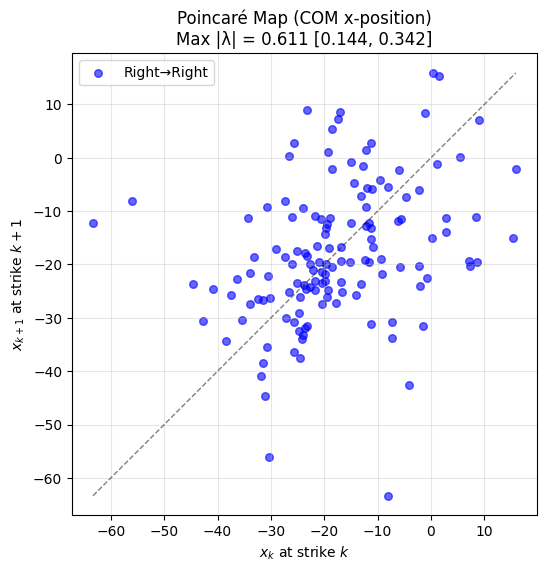


FLOQUET ANALYSIS RESULTS:
Max |Floquet λ| = 0.6108
95% Confidence Interval: [0.1441, 0.3424]
Number of cycles used: 138
Cycles trimmed from start/end: 5
Poincaré section type: Right

Running phase-dependent Floquet analysis...
Using Right-to-Right strides: 148 strides


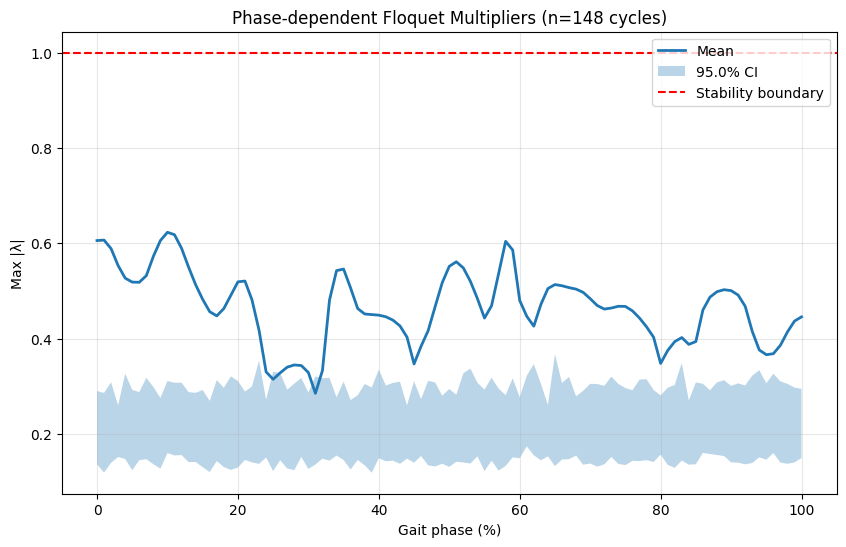


Most stable phase: 31% of gait cycle (λ = 0.2849)
Least stable phase: 10% of gait cycle (λ = 0.6230)


In [90]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Import the improved compute_floquet_from_events function
# from floquet_analysis import compute_floquet_from_events


def main():
    cwd = Path.cwd()
    print("Current working directory:", cwd.resolve())

    # ——————————————————————————————
    # 1) Load the full continuous markers + events
    # ——————————————————————————————
    data_path   = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_13" / "Pre.3" / "markers.nc"
    events_path = cwd.parent / ".." / "data" / "PBT" / "Young" / "Cereneo_SR_13" / "Pre"   / "Cereneo_SR_13_Fam_pre.4_events.csv"
    # data_path   = cwd.parent / ".." / "data" / "CGA" / "04" / "PWS" / "4" / "markers.nc"
    # events_path = cwd.parent / ".." /"data" / "CGA" / "04" / "PWS" / "4" / "PWS.4_events.csv"

    ds       = xr.open_dataset(data_path)
    df_all   = pd.read_csv(events_path)

    fs = 100.0
    N_STRIDES    = 150
    SKIP_SAMPLES = 1400
    skip_time    = SKIP_SAMPLES / fs

    # Get left foot off events for windowing
    left_fo = df_all.query("context=='Left' and label=='Foot Off' and time>=@skip_time")
    left_fo = left_fo.sort_values("time")
    if len(left_fo) < N_STRIDES:
        raise ValueError(f"Need ≥{N_STRIDES} left FO, got {len(left_fo)}")

    first_n = left_fo.iloc[:N_STRIDES]
    start_time, end_time = first_n.time.iloc[0], first_n.time.iloc[-1]
    print(f"Using strides from {start_time:.2f}s to {end_time:.2f}s (first {N_STRIDES} L_FO)")

    # Extract COM data window
    com = ds["markers"]
    com_window = com.sel(time=slice(start_time, end_time))

    # Get foot strike events within the window
    df_fs = df_all[df_all.label == "Foot Strike"]
    df_window = df_fs[(df_fs.time >= start_time) & (df_fs.time <= end_time)].copy()
    print(f"Using {len(df_window)} foot‐strike events for Floquet segmentation")

    # ——————————————————————————————
    # 2) Run improved Floquet analysis with all recommendations
    # ——————————————————————————————
    print("\n" + "="*60)
    print("Running Floquet analysis with improved methodology...")
    print("="*60 + "\n")
    
    results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=False,
        plot_spectrum=False,
        # New parameters following recommendations:
        use_same_side=True,           # Recommendation 1: Use same-side Poincaré sections
        trim_cycles=5,                # Recommendation 4: Trim first/last 5 cycles
        bootstrap_n=100,              # Recommendation 2: Bootstrap for confidence intervals
        bootstrap_ci=95.0,            # 95% confidence interval
        lowpass_cutoff=8.0,          # Recommendation 3: 8 Hz low-pass filter
        min_cycles_required=150       # Recommendation 2: Require at least 150 cycles
    )
    
    # Display results
    print("\n" + "="*60)
    print("FLOQUET ANALYSIS RESULTS:")
    print("="*60)
    print(f"Max |Floquet λ| = {results['max_floquet']:.4f}")
    print(f"95% Confidence Interval: [{results['confidence_interval'][0]:.4f}, {results['confidence_interval'][1]:.4f}]")
    print(f"Number of cycles used: {results['n_cycles_used']}")
    print(f"Cycles trimmed from start/end: {results['trimmed_cycles']}")
    print(f"Poincaré section type: {results['side_used']}")
    print("="*60 + "\n")

    # ——————————————————————————————
    # 3) Additional analysis: Phase-dependent stability
    # ——————————————————————————————
    print("Running phase-dependent Floquet analysis...")
    phase_results = compute_floquet_from_events(
        com_da=com_window,
        events_df=df_window,
        channel="COM",
        axes=["x", "y", "z"],
        normalization_points=101,
        rcond=1e-6,
        phase_dependent=True,         # Enable phase-dependent analysis
        plot_spectrum=False,          # Don't plot spectrum for each phase
        use_same_side=True,
        trim_cycles=0,
        bootstrap_n=50,               # Fewer bootstrap iterations for speed
        bootstrap_ci=95.0,
        lowpass_cutoff=8.0,
        min_cycles_required=150
    )
    
    # Find the most/least stable phases
    max_floquet_phases = phase_results['max_floquet']
    most_stable_phase = np.argmin(max_floquet_phases)
    least_stable_phase = np.argmax(max_floquet_phases)
    
    print(f"\nMost stable phase: {most_stable_phase}% of gait cycle (λ = {max_floquet_phases[most_stable_phase]:.4f})")
    print(f"Least stable phase: {least_stable_phase}% of gait cycle (λ = {max_floquet_phases[least_stable_phase]:.4f})")

    # ——————————————————————————————
    # 4) Optional: Extract normalized trajectories for visualization
    # ——————————————————————————————
    if False:  # Set to True if you want to extract and use the normalized data
        # This section shows how to extract the same normalized data
        # that the Floquet analysis uses internally
        
        df_fs = df_window.query("label=='Foot Strike'")[['time','context']].sort_values('time')
        
        # If using same-side sections, filter for the appropriate side
        if results['side_used'] != 'both':
            side_indices = df_fs[df_fs.context == results['side_used']].index
            strike_times = df_fs.loc[side_indices, 'time'].values
        else:
            strike_times = df_fs['time'].values
        
        # Build segments
        raw_segs, raw_ts = [], []
        com_data = com_window.sel(channel="COM", axis=["x","y","z"])
        
        for i in range(len(strike_times)-1):
            t0, t1 = strike_times[i], strike_times[i+1]
            seg = (com_data
                   .sel(time=slice(t0, t1))
                   .transpose('time','axis'))
            t = seg.time.values
            if t.size < 10:  # Skip very short segments
                continue
            raw_segs.append(seg.values)
            raw_ts.append(t)
        
        # Apply low-pass filter to each segment
        from scipy import signal
        filtered_segs = []
        for seg_vals, t in zip(raw_segs, raw_ts):
            fs_seg = 1.0 / np.mean(np.diff(t))
            nyquist = 0.5 * fs_seg
            normal_cutoff = 8.0 / nyquist
            b, a = signal.butter(4, normal_cutoff, btype='low', analog=False)
            
            filtered_seg = np.zeros_like(seg_vals)
            for ax in range(seg_vals.shape[1]):
                filtered_seg[:, ax] = signal.filtfilt(b, a, seg_vals[:, ax])
            filtered_segs.append(filtered_seg)
        
        # Time-normalize
        n_cycles = len(filtered_segs)
        M = 101
        norm_t = np.linspace(0, 1, M)
        n_axes = 3
        
        com_norm = np.zeros((n_cycles, M, n_axes))
        for idx, (vals, t) in enumerate(zip(filtered_segs, raw_ts)):
            t_norm = (t - t[0])/(t[-1] - t[0])
            for ax in range(n_axes):
                com_norm[idx, :, ax] = np.interp(norm_t, t_norm, vals[:, ax])
        
        # Trim cycles
        if results['trimmed_cycles'] > 0:
            trim = results['trimmed_cycles']
            com_norm = com_norm[trim:-trim]
        
        # Compute velocities
        dt = 1/(M-1)
        vel_norm = np.zeros_like(com_norm)
        vel_norm[:, 1:-1, :] = (com_norm[:, 2:, :] - com_norm[:, :-2, :])/(2*dt)
        vel_norm[:, 0, :]     = (com_norm[:, 1, :] - com_norm[:, 0, :]) / dt
        vel_norm[:, -1, :]    = (com_norm[:, -1, :] - com_norm[:, -2, :]) / dt
        
        # Now you can use com_norm and vel_norm for additional plotting
        # plot_limit_cycle_2d(com_norm, vel_norm, rcond=1e-6)


if __name__ == "__main__":
    main()